![insomnia](insomnia.jpg)


# SleepInc: Helping you find better sleep 😴

## 📖 Background

Your client is SleepInc, a sleep health company that recently launched a sleep-tracking app called SleepScope. The app monitors sleep patterns and collects users' self-reported data on lifestyle habits. SleepInc wants to identify lifestyle, health, and demographic factors that strongly correlate with poor sleep quality. They need your help to produce visualizations and a summary of findings for their next board meeting! They need these to be easily digestible for a non-technical audience!

## 💾 The data

SleepInc has provided you with an anonymized dataset of sleep and lifestyle metrics for 374 individuals. This dataset contains average values for each person calculated over the past six months.

The dataset includes 13 columns covering sleep duration, quality, disorders, exercise, stress, diet, demographics, and other factors related to sleep health. 

| Column | Description |
|---------|----------------------------------------|  
| `Person ID` | An identifier for each individual. |
| `Gender` | The gender of the person (Male/Female). |  
| `Age` | The age of the person in years. |
| `Occupation` | The occupation or profession of the person. |
| `Sleep Duration (hours)` | The average number of hours the person sleeps per day. |
| `Quality of Sleep (scale: 1-10)` | A subjective rating of the quality of sleep, ranging from 1 to 10. |
| `Physical Activity Level (minutes/day)` | The average number of minutes the person engages in physical activity daily. |  
| `Stress Level (scale: 1-10)` | A subjective rating of the stress level experienced by the person, ranging from 1 to 10. |
| `BMI Category` | The BMI category of the person (e.g., Underweight, Normal, Overweight). |
| `Blood Pressure (systolic/diastolic)` | The average blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure. |
| `Heart Rate (bpm)` | The average resting heart rate of the person in beats per minute. |
| `Daily Steps` | The average number of steps the person takes per day. |
| `Sleep Disorder` | The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea). |

***Acknowledgments**: Laksika Tharmalingam, Kaggle: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset* (this is a fictitious dataset)

In [18]:
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

raw_data = pd.read_csv('sleep_health_data.csv')
raw_data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


## 💪 Challenge

Leverage this sleep data to analyze the relationship between lifestyle, health, demographic factors, and sleep quality. Your goal is to identify factors that correlate with poor sleep health.

Some examples:

- Examine relationships between several factors like gender, occupation, physical activity, stress levels, and sleep quality/duration. Create visualizations to present your findings.
- Produce recommendations on ways people can improve sleep health based on the patterns in the data.
- Develop an accessible summary of study findings and recommendations for improving sleep health for non-technical audiences.

## 🧑‍⚖️ Judging criteria

This competition is for helping to understand how competitions work. This competition will not be judged.

## ✅ Checklist before publishing into the competition

- Rename your workspace to make it descriptive of your work. N.B. you should leave the notebook name as notebook.ipynb.
- **Remove redundant cells** like the judging criteria, so the workbook is focused on your story.
- Make sure the workbook reads well and explains how you found your insights. 
- Try to include an **executive summary** of your recommendations at the beginning.
- Check that all the cells run without error.

## ⌛️ Time is ticking. Good luck!

# Understanding the Data and Check for Missing Data

<AxesSubplot: >

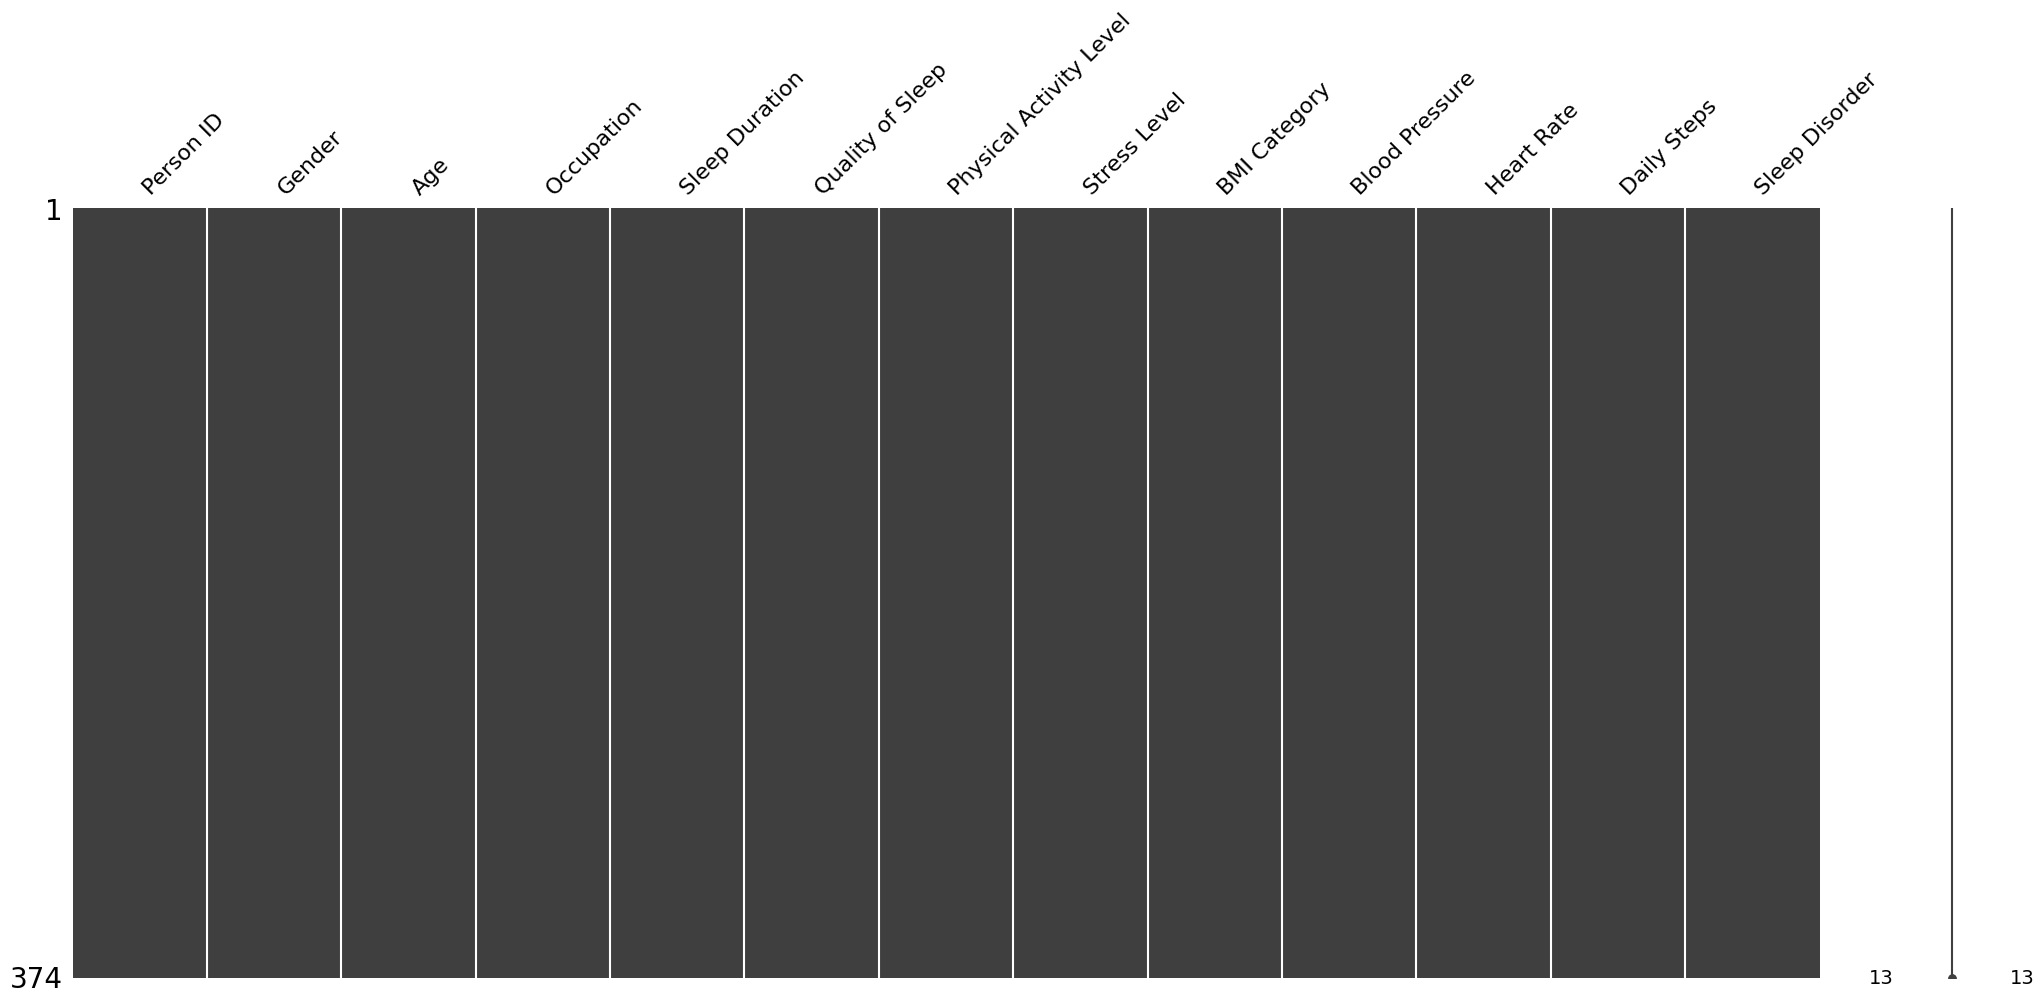

In [19]:
# Check if there is missing data
msno.matrix(raw_data)

In [20]:
# Get info on the data
print(raw_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
None


In [21]:
# Get all columns from the data
print(raw_data.columns)

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')


# Find the average sleep duration for each BMI category

In [22]:
# Find the average sleep duration for each BMI category
sleep_duration_per_category = raw_data.groupby('BMI Category')['Sleep Duration'].mean().reset_index()
sleep_duration_per_category

,BMI Category,Sleep Duration
0,Normal,7.393846
1,Normal Weight,7.333333
2,Obese,6.960000
3,Overweight,6.770270


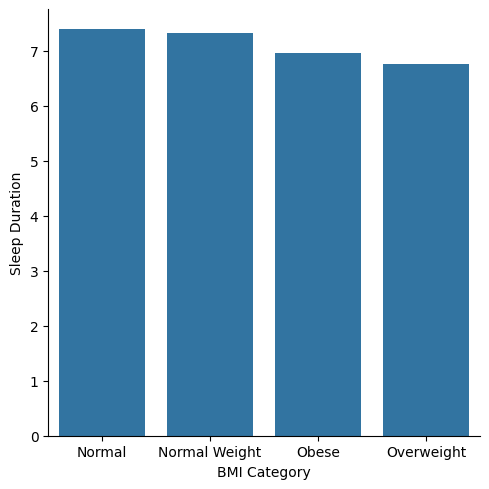

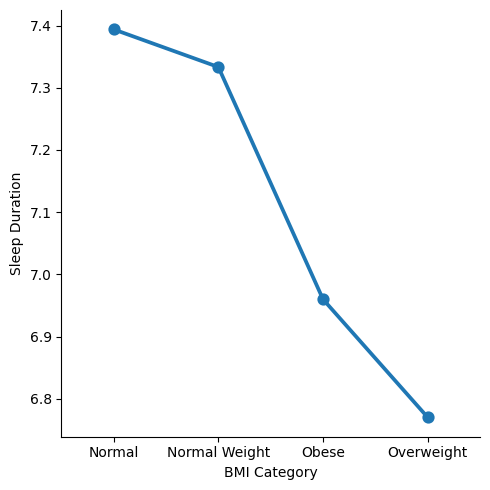

In [23]:
# Visualize the average sleep duration for each BMI category
sns.catplot(kind='bar', data=sleep_duration_per_category, x='BMI Category', y='Sleep Duration')
sns.catplot(kind='point', data=sleep_duration_per_category, x='BMI Category', y='Sleep Duration')

# Correlation between BMI Category and Sleep Duration
From the graph above, we can infer that a higher BMI score means you will have less sleep duration.

# Find the average age for each BMI category

In [24]:
# Find the average age for each BMI category
age_per_category = raw_data.groupby('BMI Category')['Age'].mean().reset_index()
age_per_category

,BMI Category,Age
0,Normal,38.482051
1,Normal Weight,38.380952
2,Obese,38.000000
3,Overweight,47.885135


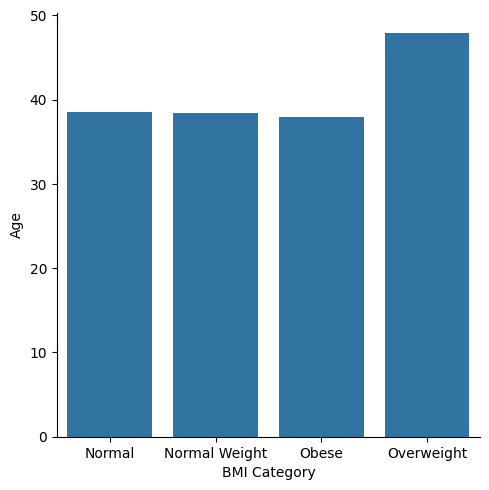

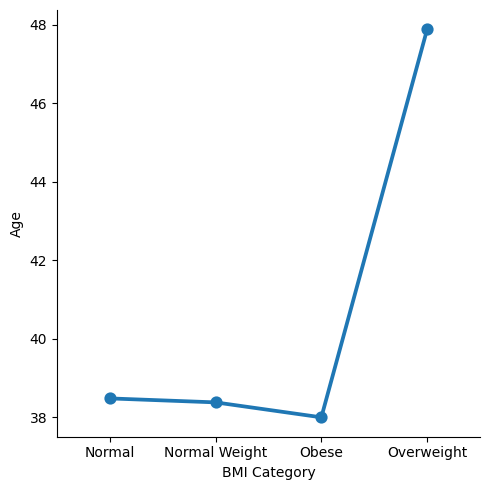

In [25]:
# Visualize the average age for each BMI category
sns.catplot(kind='bar', data=age_per_category, x='BMI Category', y='Age')
sns.catplot(kind='point', data=age_per_category, x='BMI Category', y='Age')

# Find the average quality of sleep for each BMI category

In [26]:
# Find the average quality of sleep for each BMI category
sleep_per_category = raw_data.groupby('BMI Category')['Quality of Sleep'].mean().reset_index()
sleep_per_category

,BMI Category,Quality of Sleep
0,Normal,7.661538
1,Normal Weight,7.428571
2,Obese,6.400000
3,Overweight,6.898649


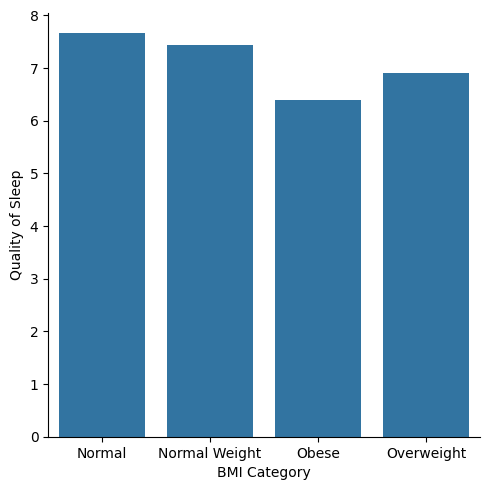

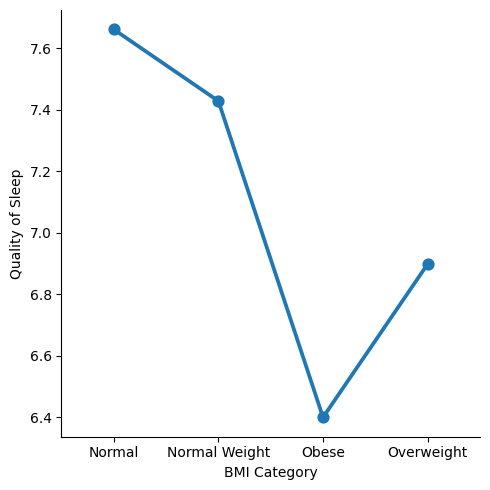

In [27]:
# Visualize the average quality of sleep for each BMI category
sns.catplot(kind='bar', data=sleep_per_category, x='BMI Category', y='Quality of Sleep')
sns.catplot(kind='point', data=sleep_per_category, x='BMI Category', y='Quality of Sleep')

# Find the average physical activity level for each BMI category

In [28]:
# Find the average physical activity level for each BMI category
activity_per_category = raw_data.groupby('BMI Category')['Physical Activity Level'].mean().reset_index()
activity_per_category

,BMI Category,Physical Activity Level
0,Normal,57.692308
1,Normal Weight,60.333333
2,Obese,55.000000
3,Overweight,61.236486


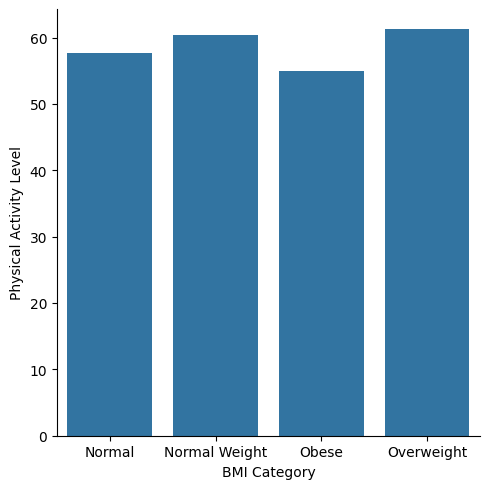

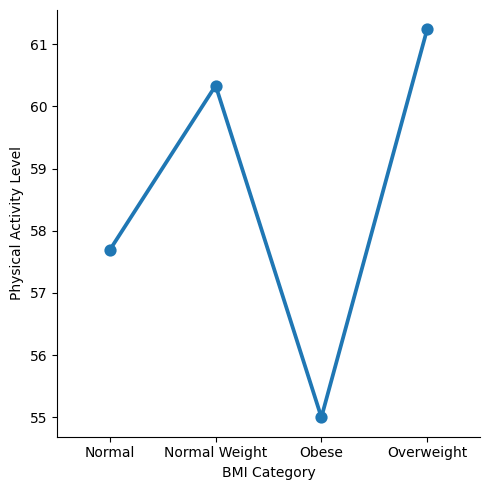

In [29]:
# Visualize the average physical activity level for each BMI category
sns.catplot(kind='bar', data=activity_per_category, x='BMI Category', y='Physical Activity Level')
sns.catplot(kind='point', data=activity_per_category, x='BMI Category', y='Physical Activity Level')

# Find the average stress level for each BMI category

In [30]:
# Find the average stress level for each BMI category
stress_per_category = raw_data.groupby('BMI Category')['Stress Level'].mean().reset_index()
stress_per_category

,BMI Category,Stress Level
0,Normal,5.128205
1,Normal Weight,5.190476
2,Obese,5.700000
3,Overweight,5.729730


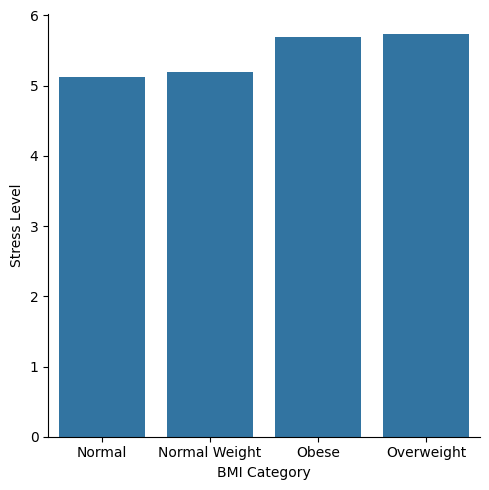

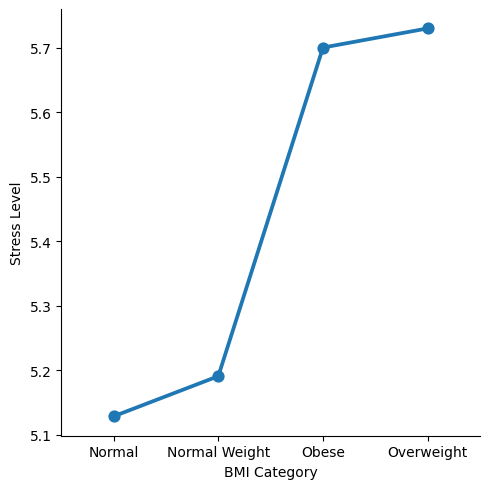

In [31]:
# Visualize the average stress level for each BMI category
sns.catplot(kind='bar', data=stress_per_category, x='BMI Category', y='Stress Level')
sns.catplot(kind='point', data=stress_per_category, x='BMI Category', y='Stress Level')

# Correlation between BMI Category and Stress Level
From the graph above, we can infer that a higher BMI score means you will have a higher stress level.

# Find the average blood pressure for each BMI category

In [32]:
# Find the average blood pressure for each BMI category

# First, we extract the systolic and diastolic blood pressure using regex
raw_data.insert(9, 'Systolic Blood Pressure', raw_data['Blood Pressure'].str.extract(r'(\d+)/'))
raw_data.insert(10, 'Diastolic Blood Pressure', raw_data['Blood Pressure'].str.extract(r'/(\d+)'))
raw_data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Systolic Blood Pressure,Diastolic Blood Pressure,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126,83,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125,80,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125,80,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140,90,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140,90,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140,95,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140,95,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140,95,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140,95,140/95,68,7000,Sleep Apnea


In [33]:
# Check the data type for columns systolic and diastolic
print(raw_data['Systolic Blood Pressure'].dtype)
print(raw_data['Diastolic Blood Pressure'].dtype)

object
object


In [34]:
# Change dtype from object to int
raw_data['Systolic Blood Pressure'] = raw_data['Systolic Blood Pressure'].astype('int')
raw_data['Diastolic Blood Pressure'] = raw_data['Diastolic Blood Pressure'].astype('int')

print(raw_data['Systolic Blood Pressure'].dtype)
print(raw_data['Diastolic Blood Pressure'].dtype)

int64
int64


In [35]:
# Find the average value for each category
systolic_blood_pressure_per_category = raw_data.groupby('BMI Category')['Systolic Blood Pressure'].mean().reset_index()
systolic_blood_pressure_per_category

,BMI Category,Systolic Blood Pressure
0,Normal,123.820513
1,Normal Weight,121.619048
2,Obese,139.200000
3,Overweight,135.054054


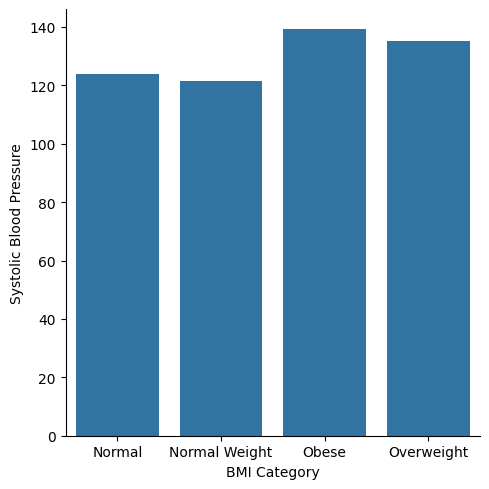

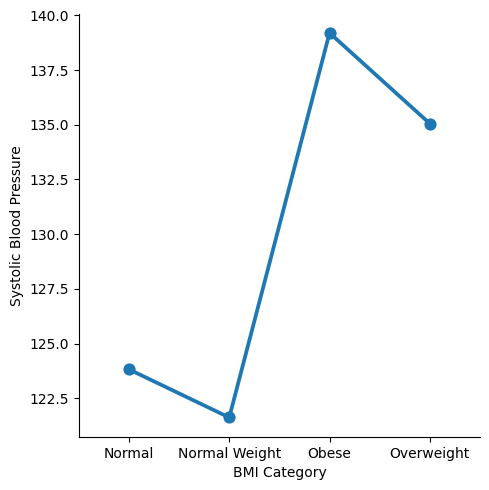

In [36]:
# Visualize the average value for each category
sns.catplot(kind='bar', data=systolic_blood_pressure_per_category, x='BMI Category', y='Systolic Blood Pressure')
sns.catplot(kind='point', data=systolic_blood_pressure_per_category, x='BMI Category', y='Systolic Blood Pressure')

In [37]:
# Find the average value for each category
diastolic_blood_pressure_per_category = raw_data.groupby('BMI Category')['Diastolic Blood Pressure'].mean().reset_index()
diastolic_blood_pressure_per_category

,BMI Category,Diastolic Blood Pressure
0,Normal,80.666667
1,Normal Weight,80.000000
2,Obese,90.200000
3,Overweight,90.182432


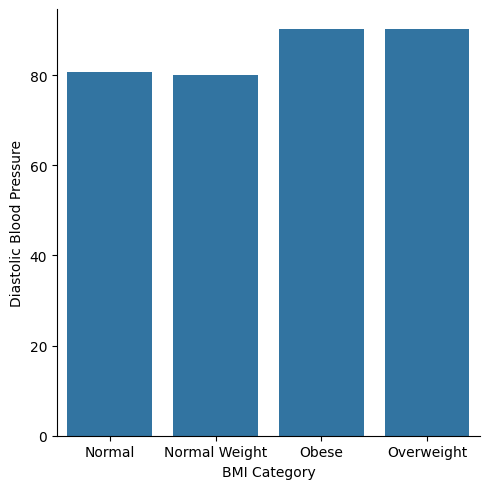

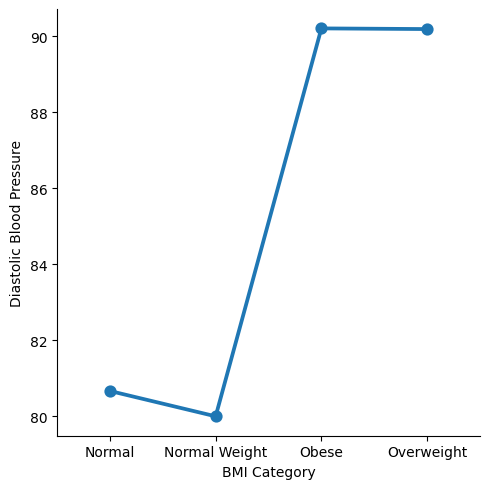

In [38]:
# Visualize the average value for each category
sns.catplot(kind='bar', data=diastolic_blood_pressure_per_category, x='BMI Category', y='Diastolic Blood Pressure')
sns.catplot(kind='point', data=diastolic_blood_pressure_per_category, x='BMI Category', y='Diastolic Blood Pressure')

# Find the average heart rate for each BMI category

In [39]:
# Find the average heart rate for each BMI category
heart_rate_per_category = raw_data.groupby('BMI Category')['Heart Rate'].mean().reset_index()
heart_rate_per_category

,BMI Category,Heart Rate
0,Normal,68.728205
1,Normal Weight,71.285714
2,Obese,84.300000
3,Overweight,70.945946


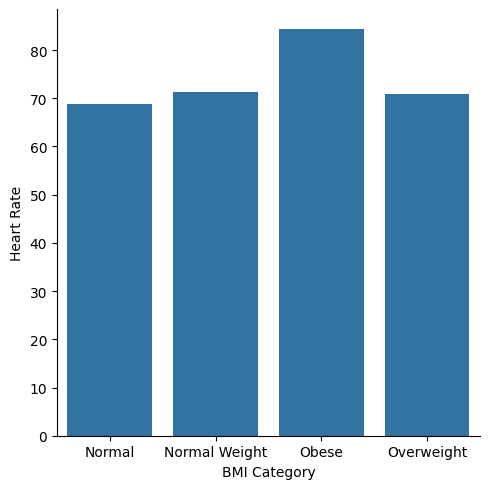

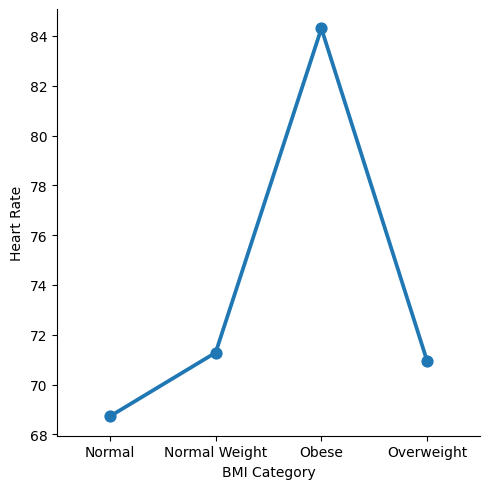

In [40]:
# Visualize the average heart rate for each BMI category
sns.catplot(kind='bar', data=heart_rate_per_category, x='BMI Category', y='Heart Rate')
sns.catplot(kind='point', data=heart_rate_per_category, x='BMI Category', y='Heart Rate')

# Find the average daily steps for each BMI category

In [41]:
# Find the average daily steps for each BMI category
daily_steps_per_category = raw_data.groupby('BMI Category')['Daily Steps'].mean().reset_index()
daily_steps_per_category

,BMI Category,Daily Steps
0,Normal,6887.179487
1,Normal Weight,6766.666667
2,Obese,3350.000000
3,Overweight,6965.540541


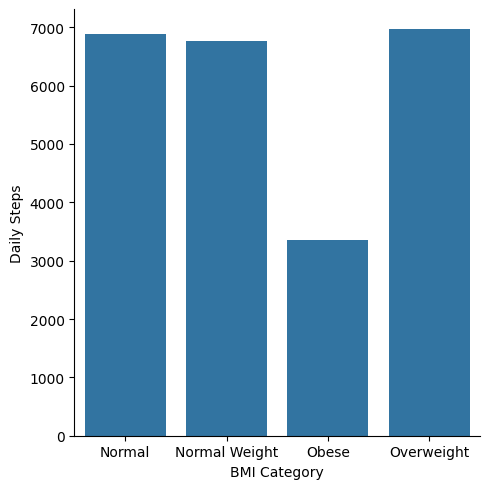

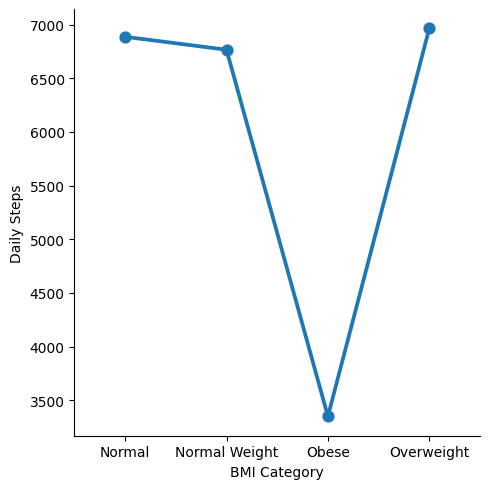

In [42]:
# Visualize the average daily steps for each BMI category
sns.catplot(kind='bar', data=daily_steps_per_category, x='BMI Category', y='Daily Steps')
sns.catplot(kind='point', data=daily_steps_per_category, x='BMI Category', y='Daily Steps')

# Find Correlation between Each Columns

In [43]:
# Show correlation between each columns using pearson method
raw_data.corr(method='pearson')

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Systolic Blood Pressure,Diastolic Blood Pressure,Heart Rate,Daily Steps
Person ID,1.000000,0.990516,0.296305,0.431612,0.149882,-0.394287,0.611551,0.590670,-0.225467,0.043844
Age,0.990516,1.000000,0.344709,0.473734,0.178993,-0.422344,0.605878,0.593839,-0.225606,0.057973
Sleep Duration,0.296305,0.344709,1.000000,0.883213,0.212360,-0.811023,-0.180406,-0.166570,-0.516455,-0.039533
Quality of Sleep,0.431612,0.473734,0.883213,1.000000,0.192896,-0.898752,-0.121632,-0.110151,-0.659865,0.016791
Physical Activity Level,0.149882,0.178993,0.212360,0.192896,1.000000,-0.034134,0.265416,0.382651,0.136971,0.772723
Stress Level,-0.394287,-0.422344,-0.811023,-0.898752,-0.034134,1.000000,0.102818,0.091811,0.670026,0.186829
Systolic Blood Pressure,0.611551,0.605878,-0.180406,-0.121632,0.265416,0.102818,1.000000,0.972885,0.294143,0.103342
Diastolic Blood Pressure,0.590670,0.593839,-0.166570,-0.110151,0.382651,0.091811,0.972885,1.000000,0.271092,0.241986
Heart Rate,-0.225467,-0.225606,-0.516455,-0.659865,0.136971,0.670026,0.294143,0.271092,1.000000,-0.030309
Daily Steps,0.043844,0.057973,-0.039533,0.016791,0.772723,0.186829,0.103342,0.241986,-0.030309,1.000000


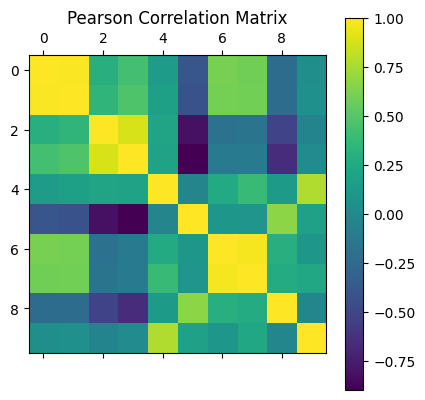

In [44]:
# Visualize correlation between each columns using pearson method
plt.matshow(raw_data.corr(method='pearson'))
plt.title('Pearson Correlation Matrix')
plt.colorbar()
plt.show()

In [45]:
# Show correlation between each columns using kendall method
raw_data.corr(method='kendall')

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Systolic Blood Pressure,Diastolic Blood Pressure,Heart Rate,Daily Steps
Person ID,1.000000,0.978347,0.160392,0.304392,0.075956,-0.299832,0.467317,0.442310,-0.156684,-0.024335
Age,0.978347,1.000000,0.159054,0.308994,0.073358,-0.305295,0.479652,0.454205,-0.160750,-0.027928
Sleep Duration,0.160392,0.159054,1.000000,0.760054,0.260274,-0.654836,-0.113139,-0.120196,-0.461024,0.041806
Quality of Sleep,0.304392,0.308994,0.760054,1.000000,0.174731,-0.825988,-0.111458,-0.127946,-0.640797,0.010615
Physical Activity Level,0.075956,0.073358,0.260274,0.174731,1.000000,-0.038977,0.212848,0.272132,0.151789,0.704973
Stress Level,-0.299832,-0.305295,-0.654836,-0.825988,-0.038977,1.000000,0.056382,0.066641,0.713878,0.154007
Systolic Blood Pressure,0.467317,0.479652,-0.113139,-0.111458,0.212848,0.056382,1.000000,0.954528,0.190994,0.090335
Diastolic Blood Pressure,0.442310,0.454205,-0.120196,-0.127946,0.272132,0.066641,0.954528,1.000000,0.203446,0.153047
Heart Rate,-0.156684,-0.160750,-0.461024,-0.640797,0.151789,0.713878,0.190994,0.203446,1.000000,0.114478
Daily Steps,-0.024335,-0.027928,0.041806,0.010615,0.704973,0.154007,0.090335,0.153047,0.114478,1.000000


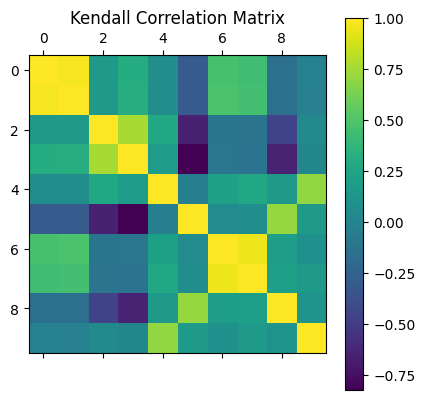

In [46]:
# Visualize correlation between each columns using kendall method
plt.matshow(raw_data.corr(method='kendall'))
plt.title('Kendall Correlation Matrix')
plt.colorbar()
plt.show()

# Find the count grouped by BMI Category and Gender

In [50]:
# Find the count grouped by BMI Category and Gender
raw_data.groupby(['Gender', 'BMI Category'])['Person ID'].count()

Gender  BMI Category 
Female  Normal            64
        Normal Weight     14
        Obese              1
        Overweight       106
Male    Normal           131
        Normal Weight      7
        Obese              9
        Overweight        42
Name: Person ID, dtype: int64

# Find the count grouped by BMI Category and Occupation

In [51]:
# Find the count grouped by BMI Category and Occupation
raw_data.groupby(['Occupation', 'BMI Category'])['Person ID'].count()

Occupation            BMI Category 
Accountant            Normal           26
                      Normal Weight     5
                      Overweight        6
Doctor                Normal           65
                      Normal Weight     2
                      Obese             4
Engineer              Normal           56
                      Normal Weight     4
                      Overweight        3
Lawyer                Normal           42
                      Normal Weight     1
                      Obese             2
                      Overweight        2
Manager               Overweight        1
Nurse                 Normal Weight     7
                      Overweight       66
Sales Representative  Obese             2
Salesperson           Overweight       32
Scientist             Overweight        4
Software Engineer     Normal Weight     2
                      Obese             1
                      Overweight        1
Teacher               Normal            

# Occupation with the Highest BMI Value
From the table above, we can infer that the occupation `Nurse` has the highest BMI value: the amount of `Overweight` people is 66.

# Find the count grouped by BMI Category and Sleep Disorder

In [52]:
# Find the count grouped by BMI Category and Sleep Disorder
raw_data.groupby(['Sleep Disorder', 'BMI Category'])['Person ID'].count()

Sleep Disorder  BMI Category 
Insomnia        Normal             7
                Normal Weight      2
                Obese              4
                Overweight        64
None            Normal           183
                Normal Weight     17
                Overweight        19
Sleep Apnea     Normal             5
                Normal Weight      2
                Obese              6
                Overweight        65
Name: Person ID, dtype: int64

# Overweight People are More Likely to Get a Sleep Disorder
From the table above, we can infer that `Overweight` people are more likely to get insomnia and sleep apnea.

# Summary: Things to Do to Get a Better Sleep
From the tables and graphs above, we can infer that people that is `Normal` has a low stress level, a high sleep quality, and a low amount of them have a sleep disorder. To be a `Normal` person, we can analyze the `Physical Activity Level`, `Daily Steps`, and `Sleep Duration` columns of these `Normal` people.

From the `Daily Steps` column, we can see a trend among `Normal`, `Normal Weight`, and `Obese`: higher amount of steps means you're more likely to be `Normal`. However, this doesn't apply to the `Overweight` people. So, a higher amount of steps doesn't guarantee you to be `Normal`. This is the same for the `Physical Activity Level` column.

From the `Sleep Duration` column, we can see a trend among `Normal`, `Normal Weight`, `Obese`, and `Overweight`: longer duration of sleep means you're more likely to be `Normal`. Therefore, we can conclude that sleep duration affect the BMI value. You need to sleep more to become `Normal`.